# <center>Tarea 3</center>

**Instrucciones:**

1. Nombra tu archivo `tarea_3.ipynb` (5 puntos).
2. Escribe tu nombre completo y, después, esta declaración:
   *Este trabajo es mío y sigue la integridad académica del Tec de
   Monterrey. La transcripción de IA que entrego corresponde
   íntegramente a este trabajo.*
3. Anota los nombres de los compañeros con quienes discutiste la
   tarea.
4. Uso de IA: permitido. Adjunta la transcripción completa de tus
   conversaciones (archivo aparte o celda al final). Sin
   transcripción, la tarea no se califica. Si no usaste IA,
   decláralo.
5. Incluye la sección final de **Verificación**.
6. Descarga tu `.ipynb` y súbelo a Canvas junto con la transcripción.

**Datos:** para esta tarea usarás varios datasets; todos están en la carpeta
`../data/tidy/` (`billboard.csv`, `fish_encounters.csv`, `us_rent_income.csv`,
`who.csv`, `world_bank_pop.csv`).

**Puntos:** nombre y declaración 5 · Tidy 25 · Tidying case study 20 · Unseen
untidy data 15 · El join traicionero 20 · Verificación 15 = **100**

## Tidy (25 puntos)

1. La base `billboard` tiene las 100 canciones en Billboard del año 2000.
    1. ¿Es tidy esta base?
    2. Si no es tidy, identifica el problema y resuélvelo
    3. Ten cuidado con los missing values. ¿Los necesitamos en la base final?
2. La base `fish_encounters` tiene información del monitoreo de peces que nadan en un río
    1. ¿Es tidy esta base?
    2. Si no es tidy, identifica el problema y resuélvelo
    3. ¿Hay missing values? ¿Qué quieren decir los missings en esta base?
3. La base `us_rent_income` muestra el ingreso en 2017 en Estados Unidos por estado. Los datos vienen de la American Community Survey.
    1. ¿Es tidy esta base?
    2. Si no es tidy, identifica el problema y resuélvelo
    3. ¿Por qué esta base es distinta a las dos anteriores?
4. Usando la base `soccer` definida en la celda de abajo, contesta lo siguiente
    1. ¿Qué errores encuentras en esta base?
    2. ¿Qué pasa si aplicas `pivot_table` sin resolver el error? ¿Qué mide cada renglón?
    3. Arregla la base y transfórmala para que nos muestre en los renglones el partido, en las columnas el jugador y en las celdas el total de goles por partido
5. Vuelve la base `preg` tidy. ¿Cuáles son las variables?

In [ ]:
import numpy as np
import pandas as pd

## 4:
data = {
    'player': ['Messi', 'Messi', 'Messi', 'Messi', 'Griezmann', 'Griezmann'],
    'game': ['Real Sociedad', 'Huesca', 'Real Sociedad', 'Huesca', 'Real Sociedad', 'Huesca'],
    'goals': [2, 2, 0, 1, 1, 1]
}
soccer = pd.DataFrame(data)

## 5:
data2 = {
    'pregnant': ['yes', 'no'],
    'male': [np.nan, 20],
    'female': [10, 12]
}
preg = pd.DataFrame(data2)

## Tidying case study: paso a paso (20 puntos)

Para este ejercicio vamos a usar la base de datos `who` (`../data/tidy/who.csv`). Carga el dataframe y contesta lo siguiente:
1. ¿Hay missing values implícitos en estos datos? ¿Cuántos implicit missing values hay? ¿Por qué faltan estos valores? Si no hay, muestra cómo puedes comprobar que no hay
2. ¿Cuántos pares country-year faltan explícitamente en la base?
3. ¿Cuál es la diferencia entre un `NA` y un cero?
4. Junta todas las variables entre `new_sp_m014` y `newrel_f65` en una sola columna llamada `key` y los valores en una columna llamada `casos`
5. Tira los missings de la base anterior
6. ¿Cuántos valores únicos hay en `key`?
7. La variable `key` tiene la siguiente estructura:
   * Las primeras 3 letras nos dicen si son nuevos `new` o viejos `old` casos de TB. En esta base todos son `new`
   * Las siguientes dos letras describen el tipo de tuberculosis: `rel` (recaída), `ep` (extra pulmonar), `sn` (pulmonar con frotis pulmonar negativo), `sp` (pulmonar con frotis pulmonar positivo)
   * La siguiente letra nos da el sexo del paciente: `m` hombres y `f` mujeres
   * Los últimos números nos dan el grupo de edad:
       * 014 = 0 – 14 years old
       * 1524 = 15 – 24 years old
       * 2534 = 25 – 34 years old
       * 3544 = 35 – 44 years old
       * 4554 = 45 – 54 years old
       * 5564 = 55 – 64 years old
       * 65 = 65 or older
   * Los nombres son inconsistentes: algunos son `newrel` y otros `new_rel`

   1. Utiliza toda esta información para crear las siguientes variables:
        1. Variable que nos diga el tipo de tuberculosis: `rel`, `ep`, `sn`, `sp`
        2. Variable que nos diga el sexo
        3. Variable que nos diga el grupo de edad
8. Tira las variables que sean redundantes de la base
9. Comprueba que tus datos ya sean tidy después de todo esto
10. Para cada país, año y sexo calcula la cantidad de casos de tuberculosis

## Unseen untidy data (15 puntos)
1. La base de datos `world_bank_pop` no es tidy. Hazla tidy, muestra cada uno de los pasos y escribe un par de oraciones que describan qué hiciste. Tu base final se tiene que ver más o menos así:

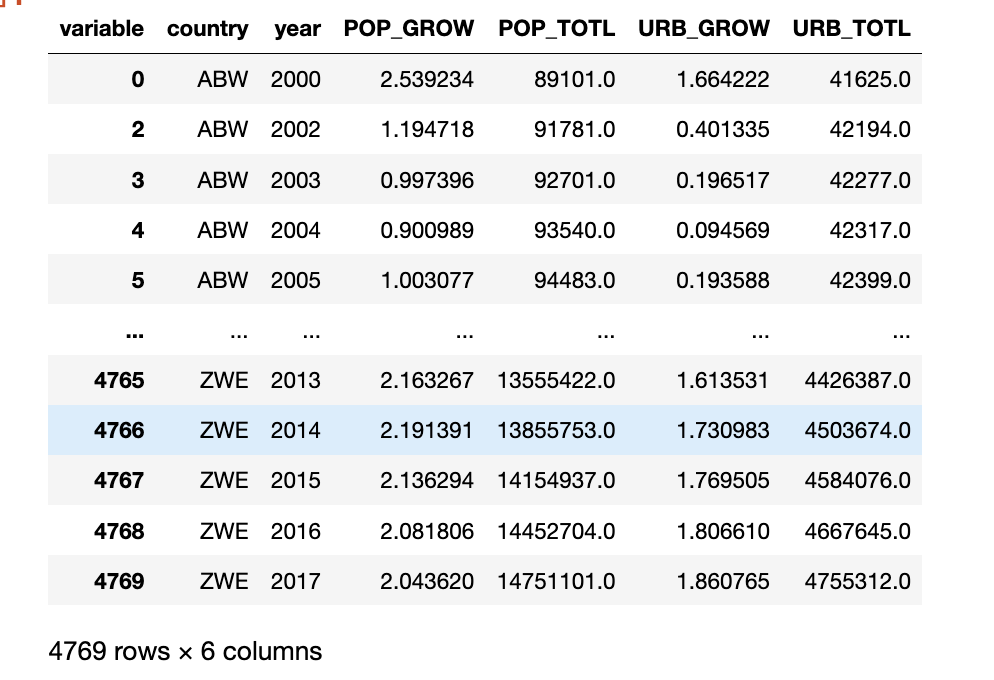

## El join traicionero (20 puntos)

Hasta aquí reacomodaste bases de una en una. Ahora vas a **pegar dos**, que es
donde se pierde la mitad de los análisis del mundo real. Los datos son de
juguete a propósito: quince renglones que puedes contar con el dedo, para que no
haya forma de esconderse detrás del tamaño de la base.

Corre la celda de abajo y luego contesta.

Escenario: `goles` tiene los goles que metió cada jugador en cada partido.
`fichajes` dice en qué club estaba cada jugador. Quieres una sola tabla con
goles **y** club para poder responder "¿cuántos goles metió cada club?".

In [ ]:
import pandas as pd

goles = pd.DataFrame({
    'jugador': ['Messi', 'Messi', 'Griezmann', 'Griezmann',
                'Suárez', 'Suárez', 'Dembélé'],
    'partido': ['Real Sociedad', 'Huesca', 'Real Sociedad', 'Huesca',
                'Real Sociedad', 'Huesca', 'Huesca'],
    'goles': [2, 1, 1, 0, 3, 2, 1]
})

fichajes = pd.DataFrame({
    'jugador': ['Messi', 'Griezmann', 'Griezmann', 'Suárez'],
    'club': ['FC Barcelona', 'Atlético Madrid', 'FC Barcelona', 'FC Barcelona'],
    'temporada': ['2018-19', '2018-19', '2019-20', '2018-19']
})

### Las preguntas

1. **Antes de hacer nada (3 puntos).** Mira las dos tablas impresas y contesta
   *sin* correr un merge:
    1. ¿Cuál es la **unidad de observación** de `goles`? ¿Y la de `fichajes`?
       Es decir: ¿qué combinación de columnas identifica un renglón único en
       cada una?
    2. Si pegas las dos tablas por `jugador`, ¿cuántos renglones esperas que
       tenga el resultado? Escribe tu predicción **antes** de correrlo. Vale
       igual si le atinas o no; lo que se califica es que la escribiste antes.

2. **El merge ingenuo (4 puntos).** Haz
   `pd.merge(goles, fichajes, on='jugador')`. Reporta:
    - renglones de `goles`, renglones de `fichajes`, renglones del resultado;
    - la suma de la columna `goles` **antes** y **después** del merge.

   Compara con tu predicción del punto 1 e imprime el resultado completo: son
   pocos renglones, léelos.

3. **La trampa (5 puntos).** Con lo que acabas de imprimir:
    1. Aquí pasaron **dos** cosas distintas: unos renglones se multiplicaron y
       otro desapareció. Identifica cuál jugador sufrió cada cosa y por qué.
    2. La suma de goles **no cambió**. Explica por qué eso no es evidencia de
       que el merge salió bien — de hecho es una coincidencia bastante
       desafortunada. ¿Qué tuvo que pasar para que los dos errores se
       cancelaran en el total?
    3. Si ahora calculas los goles por club sobre la base pegada, ¿qué número te
       da y por qué está mal? Calcúlalo y muéstralo.

4. **Diagnóstico mecánico (4 puntos).** Reproduce el problema con herramientas
   que sirvan cuando la base tenga medio millón de renglones y no puedas leerla
   a ojo:
    1. Comprueba si `jugador` es llave única en cada tabla (por ejemplo con
       `.duplicated()` o comparando `nunique()` contra `len()`). Di en cuál lo
       es y en cuál no.
    2. Corre el mismo merge con `validate='m:1'` y pega el error que te da.
       ¿Qué te habría ahorrado ponerlo desde el principio?
    3. Corre el merge con `how='left'` e `indicator=True` y reporta el conteo de
       la columna `_merge`. ¿Qué renglón aparece como `left_only` y qué implica
       eso para tu respuesta?

5. **La corrección (4 puntos).** Arregla el merge de **dos** maneras distintas:
    1. **Desduplicando primero:** deja `fichajes` con un solo renglón por
       jugador y vuelve a pegar.
    2. **Agregando primero:** colapsa `goles` a un renglón por jugador y luego
       pega.

   Reporta los renglones y la suma de goles de cada versión. Después contesta lo
   importante: para desduplicar `fichajes` tuviste que **decidir** algo que los
   datos no te dicen. ¿Qué decidiste y con qué criterio? ¿Cambia la respuesta a
   "¿cuántos goles metió cada club?" según lo que hayas decidido? Si las dos
   correcciones te dan totales distintos, explica cuál responde de verdad la
   pregunta original y cuál cambió la pregunta.

## Verificación (15 puntos)

Sección obligatoria. Aquí no se resume: se demuestra. Todo lo de esta sección va
en código, con la comprobación visible.

1. **Formas antes y después de cada reshape (6 puntos).** Para **cada** base que
   reacomodaste (`billboard`, `fish_encounters`, `us_rent_income`, `who`,
   `world_bank_pop`), escribe una comprobación en forma de `assert` con los
   números que tú esperabas, del estilo:

   ```python
   print(billboard.shape, '->', billboard_largo.shape)
   assert billboard_largo.shape[0] == 317 * 76      # sustituye por tus números
   assert billboard_largo['cancion'].nunique() == billboard.shape[0]
   ```

   Cada `assert` tiene que venir con **una línea de comentario o de texto que
   diga de dónde sale el número esperado** (renglones × columnas pivoteadas,
   países × años, etc.). Un `assert` que sólo repite lo que ya salió no
   comprueba nada: el número esperado se calcula del lado de la aritmética, no
   copiándolo de la salida.

2. **Los missings después de reacomodar (3 puntos).** Para al menos dos de las
   bases, cuenta los `NaN` antes y después del reshape y explica la diferencia.
   Un `pivot` que crea missings donde no había, o un `dropna` que se lleva
   renglones legítimos, cambia la respuesta: di si en tu caso los missings que
   quedaron son *implícitos que se volvieron explícitos* o *ausencias reales*.

3. **Llaves únicas (3 puntos).** Para tu base tidy final de `who` y para la de
   `world_bank_pop`, comprueba con código que la combinación de columnas que tú
   dices que es la llave primaria **de verdad** identifica renglones únicos
   (`df.duplicated(subset=[...]).sum() == 0`). Si no lo es, no lo tapes:
   repórtalo y explica qué lo rompe.

4. **Qué revisaste del agente (3 puntos).** Si usaste IA en cualquier parte de
   esta tarea, di qué te entregó, qué revisaste y qué encontraste — con especial
   atención a los `pivot`, `melt` y `merge`, que es donde los agentes cambian la
   unidad de observación sin avisar. En nuestra experiencia el agente siempre
   comete al menos un error o toma una decisión cuestionable; si de verdad no
   encontraste ninguno, explica qué revisaste para descartarlos. Si no usaste
   IA, decláralo.